In [42]:
import pandas as pd
import os
from utils import get_run_group_dfs_sa
import matplotlib.pyplot as plt
import numpy as np

In [43]:
all_df = pd.read_csv('metrics/SA_Queens_GridSearch/learning_curve.csv')
run_df, group_df = get_run_group_dfs_sa(all_df)

/Users/sdale/repos/personal/machine_learning/randomized_optimization/utils.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  run_df.drop_duplicates(inplace=True)
/Users/sdale/repos/personal/machine_learning/randomized_optimization/utils.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  run_df.loc[mask, f"{key}_mean"] = temp_df[key].mean()
/Users/sdale/repos/personal/machine_learning/randomized_optimization/utils.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

In [44]:
len(run_df), len(group_df)

(15, 3)

In [45]:
group_df.columns

Index(['group_number', 'problem_size', 'max_iterations', 'max_attempts',
       'start_temperature', 'decay_type', 'total_iterations_mean',
       'total_iterations_std', 'total_time_mean', 'total_time_std',
       'best_fitness_mean', 'best_fitness_std', 'total_fevals_mean',
       'total_fevals_std'],
      dtype='object')

In [46]:
max_fitness = group_df['best_fitness_mean'].max()
best_df = group_df[group_df['best_fitness_mean'] == max_fitness]
len(best_df)

1

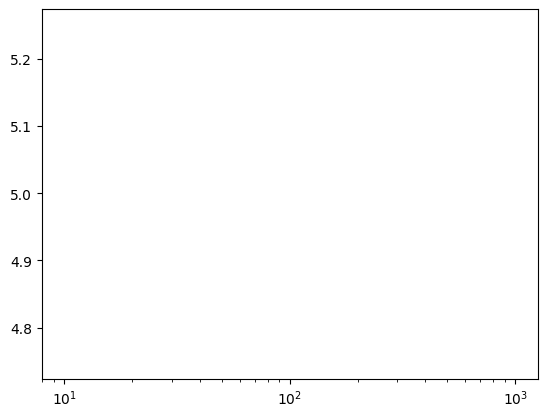

In [47]:
# s_df = best_df[best_df['start_temperature'] == 1]
s_df = best_df
plt.plot(s_df['max_attempts'], s_df['total_time_mean'])
plt.xscale('log')

In [49]:
all_df['start_temperature'].unique()

array([  1000.,  10000., 100000.])

In [48]:
best_row = best_df.sort_values('total_time_mean', ascending=True).iloc[0]
best_row

group_number                        0
problem_size                      100
max_iterations           1000000000.0
max_attempts                      100
start_temperature              1000.0
decay_type                  GeomDecay
total_iterations_mean          3929.4
total_iterations_std       730.439799
total_time_mean              4.999012
total_time_std               0.986715
best_fitness_mean                -9.2
best_fitness_std              0.83666
total_fevals_mean              4896.0
total_fevals_std           772.310818
Name: 0, dtype: object